In [25]:
import os
import zipfile
import cv2
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score,confusion_matrix, classification_report



In [26]:
import zipfile

zip_path = "/content/Plant_Disease_Workshop.zip"
extract_path = "/content/Plant_Disease_Workshop"

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted successfully!")

Dataset extracted successfully!


In [27]:
dataset_path= "/content/Plant_Disease_Workshop"
print(os.listdir("/content"))

['.config', 'Plant_Disease_Workshop', 'Plant_Disease_Workshop (1).zip', 'Plant_Disease_Workshop.zip', 'sample_data']


In [28]:

dataset_path ="/content/Plant_Disease_Workshop/Plant_Disease_Workshop/train"
print(os.listdir(dataset_path))

['Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy']


In [29]:
dataset_path ="/content/Plant_Disease_Workshop/Plant_Disease_Workshop/val"
print(os.listdir(dataset_path))

['Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy']


In [30]:
print("============== TRAIN DATA=============")
for folder in os.listdir(train_path):
  folder_path=os.path.join(train_path,folder)
  print(folder,':',len(os.listdir(folder_path)),'images')


print("\n============== VAL  DATA============\n")
for folder in os.listdir(val_path):
  folder_path=os.path.join(val_path,folder)
  print(folder,':',len(os.listdir(folder_path)),'images')

============== TRAIN DATA=============
Potato___Early_blight : 800 images
Potato___Late_blight : 800 images
Potato___healthy : 121 images

============== VAL  DATA============

Potato___Early_blight : 200 images
Potato___Late_blight : 200 images
Potato___healthy : 31 images


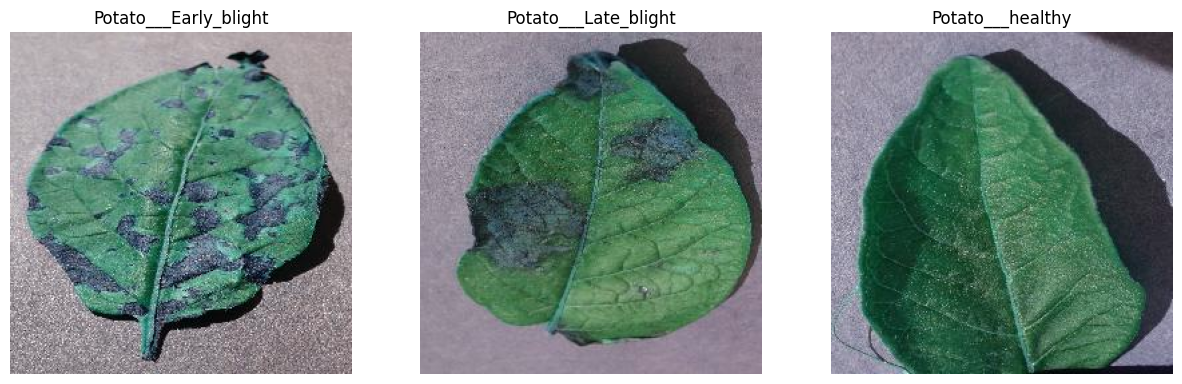

In [31]:
plt.figure(figsize=(15,5))
classes = os.listdir(train_path)
for i, folder in enumerate(classes):
  image_name = os.listdir(os.path.join(train_path,folder))[0]
  image_path = os.path.join(train_path,folder,image_name)
  image = cv2.imread(image_path)
  image - cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
  plt.subplot(1,3,i+1)
  plt.imshow(image)
  plt.title(folder)
  plt.axis("off")
plt.show()

In [32]:
train_path='/content/Plant_Disease_Workshop/Plant_Disease_Workshop/train'
val_path='/content/Plant_Disease_Workshop/Plant_Disease_Workshop/val'
image_size=(64,64)

In [33]:
X_train=[]
y_train=[]

X_val=[]
y_val=[]

In [34]:
for label in os.listdir(train_path):
  folder_path=os.path.join(train_path,label)
  for image_name in os.listdir(folder_path):
    image_path=os.path.join(folder_path,image_name)
    image=cv2.imread(image_path)
    image=cv2.resize(image,image_size)
    X_train.append(image)
    y_train.append(label)
print("Train image Loaded Successfully!")

Train image Loaded Successfully!


In [35]:
for label in os.listdir(val_path):
  folder_path=os.path.join(val_path,label)
  for image_name in os.listdir(folder_path):
    image_path=os.path.join(folder_path,image_name)
    image=cv2.imread(image_path)
    image=cv2.resize(image,image_size)
    X_val.append(image)
    y_val.append(label)
print("Valization image Loaded Successfully!")

Valization image Loaded Successfully!


In [36]:
print("Training images:",len(X_train))
print("Training labels:",len(y_train))

print()

print("Validation images:",len(X_val))
print("Validation labels:",len(y_val))

Training images: 1721
Training labels: 1721

Validation images: 431
Validation labels: 431


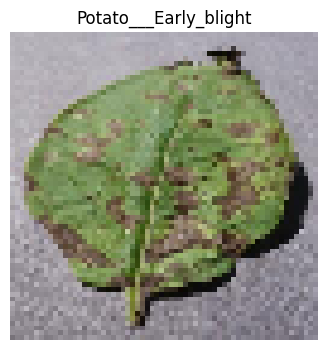

In [37]:
plt.figure(figsize=(4,4))
plt.imshow(cv2.cvtColor(X_train[0],cv2.COLOR_BGR2RGB))
plt.title(y_train[0])
plt.axis("off")
plt.show()

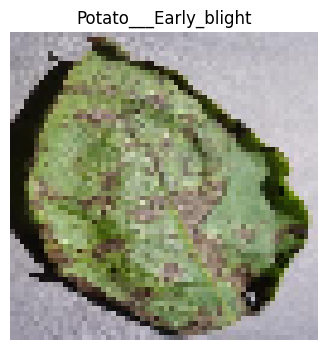

In [38]:
plt.figure(figsize=(4,4))
plt.imshow(cv2.cvtColor(X_val[0],cv2.COLOR_BGR2RGB))
plt.title(y_train[0])
plt.axis("off")
plt.show()

In [39]:
X_train=np.array(X_train)
y_train=np.array(y_train)

X_val=np.array(X_val)
y_val=np.array(y_val)
print("converted successfully!")

converted successfully!


In [40]:
print("Training Shape:", X_train.shape)
print("Validation Shape:", X_val.shape)

Training Shape: (1721, 64, 64, 3)
Validation Shape: (431, 64, 64, 3)


In [41]:
X_train= X_train.reshape(X_train.shape[0],-1)
X_val=X_val.reshape(X_val.shape[0],-1)
print("Image reshape successfullfy!")

Image reshape successfullfy!


In [42]:
X_train=X_train / 255.0
X_val=X_val / 255.0
print("Image Normalize successfullfy!")

Image Normalize successfullfy!


In [43]:
encoder = LabelEncoder()
y_train = encoder.fit_transform(y_train)
y_val = encoder.fit_transform(y_val)
print("Label Encoder successfullfy!")

Label Encoder successfullfy!


In [44]:
print("Encoder classes")
print(encoder.classes_)

print()

print("First 10 Labels:")
print(y_train[:10])

Encoder classes
['Potato___Early_blight' 'Potato___Late_blight' 'Potato___healthy']

First 10 Labels:
[0 0 0 0 0 0 0 0 0 0]


In [45]:
print("Training Features shape:",X_train.shape)
print("Training Labels shape:",y_train.shape)

print()

print("Validation Features shape:",X_val.shape)
print("Validation Labels shape:",y_val.shape)

Training Features shape: (1721, 12288)
Training Labels shape: (1721,)

Validation Features shape: (431, 12288)
Validation Labels shape: (431,)


In [46]:
logistic_model = LogisticRegression(max_iter=1000)
print("Logistic Regression model Created Successfully!")

Logistic Regression model Created Successfully!


In [47]:
logistic_model.fit(X_train,y_train)
print("model training completed")

model training completed


In [48]:
y_pred = logistic_model.predict(X_val)
print("prediction completed")

prediction completed


In [49]:
print("Actual Labels    :",y_val[:10])
print("predicted Labels    :",y_pred[:10])

Actual Labels    : [0 0 0 0 0 0 0 0 0 0]
predicted Labels    : [0 0 0 0 0 0 0 0 0 0]


In [50]:
acc = accuracy_score(y_val,y_pred)
print("Accuracy:",round(acc*100,2),"%")

Accuracy: 90.72 %


In [51]:
cmx = confusion_matrix(y_val,y_pred)
print("Confusion Matrix:")
print(cmx)

Confusion Matrix:
[[185  15   0]
 [  8 189   3]
 [  0  14  17]]


In [52]:
print(classification_report(y_val,y_pred ,target_names=encoder.classes_))

                       precision    recall  f1-score   support

Potato___Early_blight       0.96      0.93      0.94       200
 Potato___Late_blight       0.87      0.94      0.90       200
     Potato___healthy       0.85      0.55      0.67        31

             accuracy                           0.91       431
            macro avg       0.89      0.81      0.84       431
         weighted avg       0.91      0.91      0.90       431



In [53]:
predicted_labels = encoder.inverse_transform(y_pred[:10])

print("first 10 predicted Disease Names:")
print(predicted_labels)

first 10 predicted Disease Names:
['Potato___Early_blight' 'Potato___Early_blight' 'Potato___Early_blight'
 'Potato___Early_blight' 'Potato___Early_blight' 'Potato___Early_blight'
 'Potato___Early_blight' 'Potato___Early_blight' 'Potato___Early_blight'
 'Potato___Early_blight']


<function matplotlib.pyplot.show(close=None, block=None)>

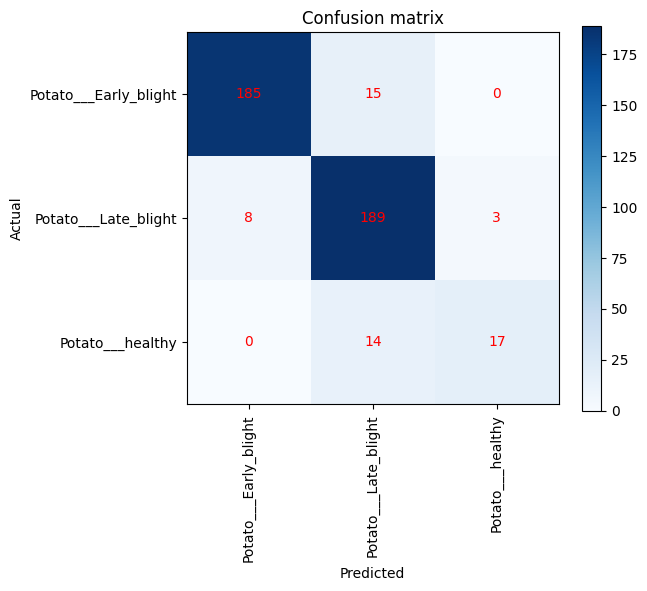

In [54]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))
plt.imshow(cmx,cmap =plt.cm.Blues)
plt.title("Confusion matrix")
plt.colorbar()

plt.xticks(range(3),encoder.classes_,rotation=90)
plt.yticks(range(3),encoder.classes_)

for i in range(len(cmx)):
  for j in range(len(cmx)):
    plt.text(j,i,cmx[i][j],
             ha ="center",
             va = "center",
             color = "red",)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show



In [55]:
print("=" * 40)
print("Logistic Regression Model")
print("=" * 40)

print(f"Accuracy: {acc* 100:.2f}%")

Logistic Regression Model
Accuracy: 90.72%


In [56]:
svm_model = SVC(kernel="linear")
print("Support vector machine model created Successfully!")


Support vector machine model created Successfully!


In [57]:
svm_model.fit(X_train,y_train)
print("Model Training is completed!")

Model Training is completed!


In [58]:
svm_acc = accuracy_score(y_val,y_pred)
print("Accuracy:",round(acc*100,2),"%")

Accuracy: 90.72 %


In [59]:
svm_cm= confusion_matrix(y_val,y_pred)
print("Confusion Matrix:")
print(cmx)

Confusion Matrix:
[[185  15   0]
 [  8 189   3]
 [  0  14  17]]


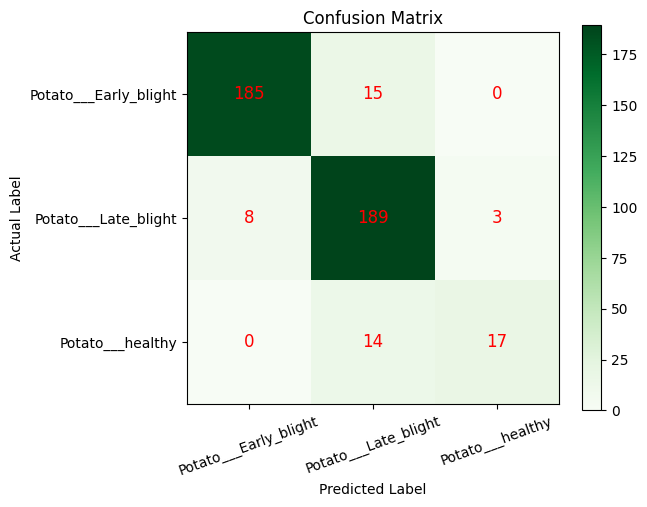

In [60]:
plt.figure(figsize=(6, 5))
plt.imshow(svm_cm, cmap='Greens')
plt.title("Confusion Matrix")
plt.colorbar()

plt.xticks(range(3), encoder.classes_, rotation=20)
plt.yticks(range(3), encoder.classes_)

for i in range(len(svm_cm)):
    for j in range(len(svm_cm)):
        plt.text(j, i, svm_cm[i, j],
                 ha='center',
                 va='center',
                 color="red",
                 fontsize=12)
        plt.xlabel('Predicted Label')
        plt.ylabel('Actual Label')

plt.show()

In [61]:
from google.colab import files
uploaded = files.upload()

Saving e9643c88-239f-4587-8093-3b96eb3723f4___RS_Early.B 7353.JPG to e9643c88-239f-4587-8093-3b96eb3723f4___RS_Early.B 7353.JPG


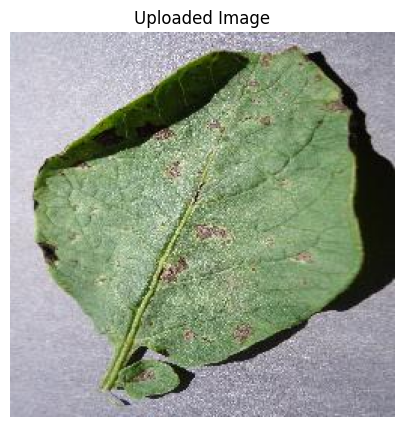

In [62]:
image_name = list(uploaded.keys())[0]

image = cv2.imread(image_name)
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(5, 5))
plt.imshow(image_rgb)
plt.title("Uploaded Image")
plt.axis("off")
plt.show()


In [63]:
test_image = cv2.resize(image,(64,64))
test_image = test_image.reshape(1, -1)
test_image = test_image / 255.0
print("image processed successfully!")

image processed successfully!


In [65]:
prediction = svm_model.predict(test_image)
predicted_Disease = encoder.inverse_transform(prediction)
print("Predicted Disease:", predicted_disease[0])

NameError: name 'predicted_disease' is not defined

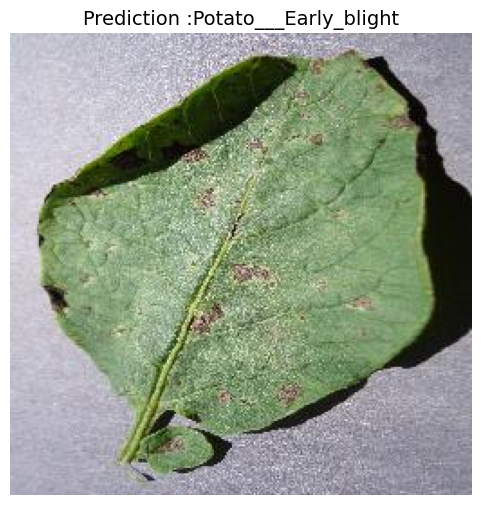

In [66]:
plt.figure(figsize=(6, 6))
plt.imshow(image_rgb)
plt.title("Prediction :"+predicted_Disease[0],fontsize=14)
plt.axis("off")
plt.show()

In [67]:
 if predicted_Disease[0] == "Potato___Early_blight":
    print("Disease: Early Blight")
    print("Advice: Remove infected leaves and apply fungicide.")
elif predicted_Disease[0] == "Potato___Late_blight":
    print("Disease: Late Blight")
    print("Advice: Remove infected leaves and apply fungicide.")
else:
  print("Disease: Healthy")
  print("Advice: No disease detected.continue regular crop care.")


Disease: Early Blight
Advice: Remove infected leaves and apply fungicide.


In [68]:
comparison = {

    "model": ["Logistic Regression", "Support Vector Machine"],
    "accuracy": [acc* 100, svm_acc* 100]
}
import pandas as pd

comparison_df = pd.DataFrame(comparison)
comparison_df


,model,accuracy
0,Logistic Regression,90.719258
1,Support Vector Machine,90.719258


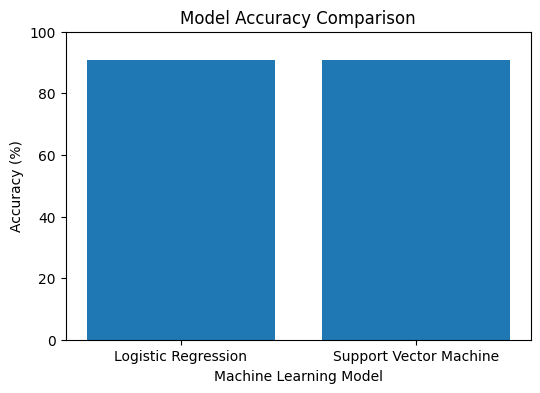

In [76]:
plt.figure(figsize=(6, 4))
plt.bar(comparison_df["model"], comparison_df["accuracy"])
plt.title("Model Accuracy Comparison")
plt.xlabel("Machine Learning Model")
plt.ylabel("Accuracy (%)")
plt.ylim(0, 100)

plt.show()


In [81]:
if acc > svm_acc:
    print("Best Model: Support Vector Machine (SVM)")
else:
    print("Best Model: Logistic Regression")

Best Model: Logistic Regression
